# Zheng et al. (2017) – Massively parallel digital transcriptional profiling of single cells

The original paper can be found here: https://www.nature.com/articles/ncomms14049

__Abstract__: Characterizing the transcriptome of individual cells is fundamental to understanding complex biological systems. We describe a droplet-based system that enables 3′ mRNA counting of tens of thousands of single cells per sample. Cell encapsulation, of up to 8 samples at a time, takes place in ∼6 min, with ∼50% cell capture efficiency. To demonstrate the system’s technical performance, we collected transcriptome data from ∼250k single cells across 29 samples. We validated the sensitivity of the system and its ability to detect rare populations using cell lines and synthetic RNAs. We profiled 68k peripheral blood mononuclear cells to demonstrate the system’s ability to characterize large immune populations. Finally, we used sequence variation in the transcriptome data to determine host and donor chimerism at single-cell resolution from bone marrow mononuclear cells isolated from transplant patients.

A 10x Chromium immune benchmark: ~14k human PBMCs assembled from FACS-sorted populations (CD14⁺ monocytes, B cells, NK, CD4/8 T, &c.). The data set is UMI-based droplet data, and can be used as a multi-class ground truth because the cells come from purified sorts.

From scMINER: The data of this study was originally collected from SRP073767 and used as a ground truth to benchmark scMINER and other tools. In this study, the authors performed single cell RNA-Seq experiment on 10 sorted populations of Peripheral Blood Mononuclear Cells (PBMCs): CD14+ Monocyte, CD19+ B, CD34+, CD4+ T Helper2, CD4+/CD25 T Reg, CD4+/CD45RA+/CD25- Naive T, CD4+/CD45RO+ Memory, CD56+ NK, CD8+ Cytotoxic T, CD8+/CD45RA+ Naive Cytotoxic. The library was prepared with GemCode Single-Cell 3′ Gel Bead and Library Kit (10x Genomics) and sequenced on NextSeq 500 (Illumina). For benchmark purpuses, we removed 3 cell populations, CD34+ cells, CD4+ helper T cells, and total CD8+ cytotoxic cells, from the dataset because of either low sorting purity or a significant overlap with other immune cells based on the sorting strategy, and created a new dataset with seven known cell types and 14k cells in total. Zheng, Grace XY, et al. "Massively parallel digital transcriptional profiling of single cells." Nature communications 8.1 (2017): 14049.

## 0. Imports & Set-Up:

In [1]:
import multiprocessing
import os, random

from pathlib import Path

from sklearn.base import ClusterMixin
from sklearn.cluster import AgglomerativeClustering, KMeans, SpectralClustering
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import MinMaxScaler

import numpy as np
import pandas as pd

import anndata as ad

import matplotlib.pyplot as plt

from carve import CARVE

In [2]:
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
os.environ["PYTHONHASHSEED"] = str(RANDOM_SEED)

In [3]:
def get_n_jobs():
    # read env override first
    env_val = os.environ.get("CARVE_N_JOBS", None)
    if env_val is not None:
        try:
            return int(env_val)
        except ValueError:
            pass 
        
    # otherwise: default = (num cores - 1)
    try:
        n_cores = multiprocessing.cpu_count()
    except NotImplementedError:
        n_cores = 4

    return max(1, n_cores - 1)

N_JOBS = get_n_jobs()
print(f"Using N_JOBS={N_JOBS} for parallel processing.")

Using N_JOBS=10 for parallel processing.


In [4]:
%env PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning,ignore::RuntimeWarning

env: PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning,ignore::RuntimeWarning


In [5]:
from functions import (
    align_labels, gamma_quantile_approx, gap_statistic, davies_bouldin_inv
)

The following cell defines a custom `LeidenClustering` class, providing a scikit-learn style interface to the Leiden community detection algorithm. This approach enables clustering of tabular data by first constructing a k-nearest neighbor (kNN) graph and then applying Leiden for community detection.

The custom `LeidenClustering` class:
- Accepts standard sklearn parameters (`n_clusters`, `n_neighbors`, `resolution`, `random_state`).
- Builds an undirected kNN graph from the input data.
- Runs Leiden via the `leidenalg` package on the constructed graph.
- Optionally relabels clusters to match the requested number of clusters (`n_clusters`), mapping the largest clusters to consecutive labels.
- Is compatible with sklearn workflows (`fit`, `fit_predict`).

This wrapper is used for benchmarking Leiden clustering alongside other sklearn algorithms below.

In [6]:
from sklearn.base import BaseEstimator
import igraph as ig
import leidenalg
from sklearn.neighbors import NearestNeighbors

class LeidenClustering(BaseEstimator, ClusterMixin):
    """
    Wrapper for Leiden community detection algorithm with sklearn interface.
    Clusters tabular data by building a k-nearest neighbor graph and running Leiden.

    Parameters:
        n_clusters (int): Desired number of clusters (approximate, Leiden may not match exactly).
        n_neighbors (int): Number of neighbors for graph construction (default: 10).
        resolution (float): Resolution parameter for Leiden (higher = more clusters, default: 1.0).
        random_state (int or None): Random seed.
    """
    def __init__(self, n_clusters=None, n_neighbors=10, resolution=1.0, random_state=None):
        self.n_clusters = n_clusters
        self.n_neighbors = n_neighbors
        self.resolution = resolution
        self.random_state = random_state

    def fit(self, X, y=None):
        # Build kNN graph
        knn = NearestNeighbors(n_neighbors=self.n_neighbors + 1, metric='euclidean')
        knn.fit(X)
        knn_graph = knn.kneighbors_graph(X, mode='connectivity')
        sources, targets = knn_graph.nonzero()
        edges = list(zip(sources.tolist(), targets.tolist()))

        # Create igraph graph
        g = ig.Graph(n=X.shape[0], edges=edges, directed=False)
        g.simplify()

        # Run Leiden
        partition = leidenalg.find_partition(
            g,
            leidenalg.RBConfigurationVertexPartition,
            resolution_parameter=self.resolution,
            seed=self.random_state
        )
        self.labels_ = np.array(partition.membership)

        # Optionally, relabel to match n_clusters if specified
        if self.n_clusters is not None and len(np.unique(self.labels_)) != self.n_clusters:
            # Map largest clusters to 0..n_clusters-1, rest to -1
            counts = np.bincount(self.labels_)
            top = np.argsort(counts)[::-1][:self.n_clusters]
            mapping = {old: new for new, old in enumerate(top)}
            self.labels_ = np.array([mapping.get(l, -1) for l in self.labels_])

        return self

    def fit_predict(self, X, y=None):
        self.fit(X, y)
        return self.labels_

---

## 1. Pre-Process the Data

In [7]:
DATA_DIR = "../data/Zheng PBMC14K"
FP_EXPR = f"{DATA_DIR}/Filtered_DownSampled_SortedPBMC_data.csv"
FP_ANN  = f"{DATA_DIR}/GRCh37.87.geneAnnotation.txt"
FP_LAB  = f"{DATA_DIR}/PBMC_20k_true_label.txt"

Read in annotation data:

In [8]:
expr = pd.read_csv(FP_EXPR, index_col=0)

# consider orientation: if rows >> cols and looks like genes x cells, transpose to cells x genes
if expr.shape[0] < expr.shape[1]:
    print('already cells x genes')
    Xdf = expr
else:
    print('genes x cells -> transpose to cells x genes')
    Xdf = expr.T

already cells x genes


Ensure numeric:

In [9]:
Xdf = Xdf.apply(pd.to_numeric, errors="coerce")
Xdf = Xdf.loc[:, Xdf.notna().any(axis=0)].fillna(0.0)

print("cells x genes:", Xdf.shape)

cells x genes: (20000, 21952)


Read true labels (txt; tab-separated with columns like ID, label):

In [10]:
lab = pd.read_csv(FP_LAB, sep="\t")
    
# try 
candidates_id = [c for c in lab.columns if c.lower() in {"id", "barcode", "cell", "cell_id"}]
candidates_lb = [c for c in lab.columns if "label" in c.lower() or "type" in c.lower() or "pop" in c.lower()]

if not candidates_id or not candidates_lb:
    print("Label columns:", lab.columns.tolist())
    raise ValueError("Could not infer ID/label columns—inspect printed columns and set manually.")

id_col, lb_col = candidates_id[0], candidates_lb[0]
lab = lab[[id_col, lb_col]].rename(columns={id_col: "cell_id", lb_col: "cell_type"})
lab["cell_id"] = lab["cell_id"].astype(str)
lab["cell_type"] = lab["cell_type"].astype("category")

lab = lab.set_index("cell_id")

Align by intersection of "cell_id":

In [11]:
common = Xdf.index.astype(str).intersection(lab.index)
if len(common) == 0:
    # Sometimes barcodes in matrix have suffixes like "-1"; try stripping
    X_index = Xdf.index.astype(str).str.replace("-1$", "", regex=True)
    Xdf.index = X_index
    common = Xdf.index.intersection(lab.index)

Xdf = Xdf.loc[common]
lab = lab.loc[common]
print("aligned cells:", Xdf.shape[0])

aligned cells: 20000


Gene annotation, add gene symbols for var:

In [12]:
ann = pd.read_csv(FP_ANN, sep="\t")

# try to guess columns
ens_cols = [c for c in ann.columns if "ensembl" in c.lower() or c.lower() in {"gene_id", "ensembl_gene_id"}]
sym_cols = [c for c in ann.columns if "symbol" in c.lower() or c.lower() in {"hgnc_symbol", "gene_name"}]

if ens_cols and sym_cols:
    ens_col, sym_col = ens_cols[0], sym_cols[0]
    ann = ann[[ens_col, sym_col]].dropna()
    ann[ens_col] = ann[ens_col].astype(str)
    ann = ann.drop_duplicates(subset=[ens_col]).set_index(ens_col)
    
    # If Xdf columns are Ensembl IDs, can map; otherwise store names as-is
    var = pd.DataFrame(index=pd.Index(Xdf.columns.astype(str), name="gene_id"))
    
    if var.index.isin(ann.index).any():
        var["gene_symbol"] = ann.reindex(var.index)[sym_col].values
    else:
        # Xdf already uses symbols?
        var = var.rename_axis("gene_symbol").copy()
else:
    var = pd.DataFrame(index=pd.Index(Xdf.columns.astype(str), name="gene_id"))

Build adata object:

In [13]:
# Remove cell populations from lab and Xdf as scMINER
exclude_types = [
    "CD34+",
    "CD4+ T Helper2",
    "CD8+ Cytotoxic T"
]
keep_cells = lab[~lab["cell_type"].isin(exclude_types)].index
Xdf = Xdf.loc[keep_cells]
lab = lab.loc[keep_cells]

adata = ad.AnnData(
    X = Xdf.values.astype(np.float32),  # raw UMI counts
    obs = pd.DataFrame(index=pd.Index(Xdf.index.astype(str), name="barcode")),
    var = var,
)
adata.obs["cell_type"] = lab["cell_type"].astype("category")
adata.layers["counts"] = adata.X.copy()  # preserve raw counts

# name hygiene so .write() works cleanly
adata.obs.columns = adata.obs.columns.astype(str)
adata.var.columns = adata.var.columns.astype(str)
adata.obs_names.name = "barcode"
adata.var_names = adata.var_names.astype(str)
adata.var_names.name = adata.var_names.name or "gene_id"

adata.obs["cell_type"] = adata.obs["cell_type"].cat.remove_unused_categories()

print(adata)
print(adata.obs["cell_type"].value_counts())

AnnData object with n_obs × n_vars = 14000 × 21952
    obs: 'cell_type'
    layers: 'counts'
cell_type
CD14+ Monocyte                  2000
CD19+ B                         2000
CD4+/CD25 T Reg                 2000
CD4+/CD45RA+/CD25- Naive T      2000
CD4+/CD45RO+ Memory             2000
CD56+ NK                        2000
CD8+/CD45RA+ Naive Cytotoxic    2000
Name: count, dtype: int64


---

## 2. Analyse Data

In [14]:
# Extract X (features) and y (labels)
X = Xdf.values
X = np.log1p(X)

y = lab['cell_type']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Number of unique cell types in y: {y.nunique()}")

X shape: (14000, 21952)
y shape: (14000,)
Number of unique cell types in y: 7


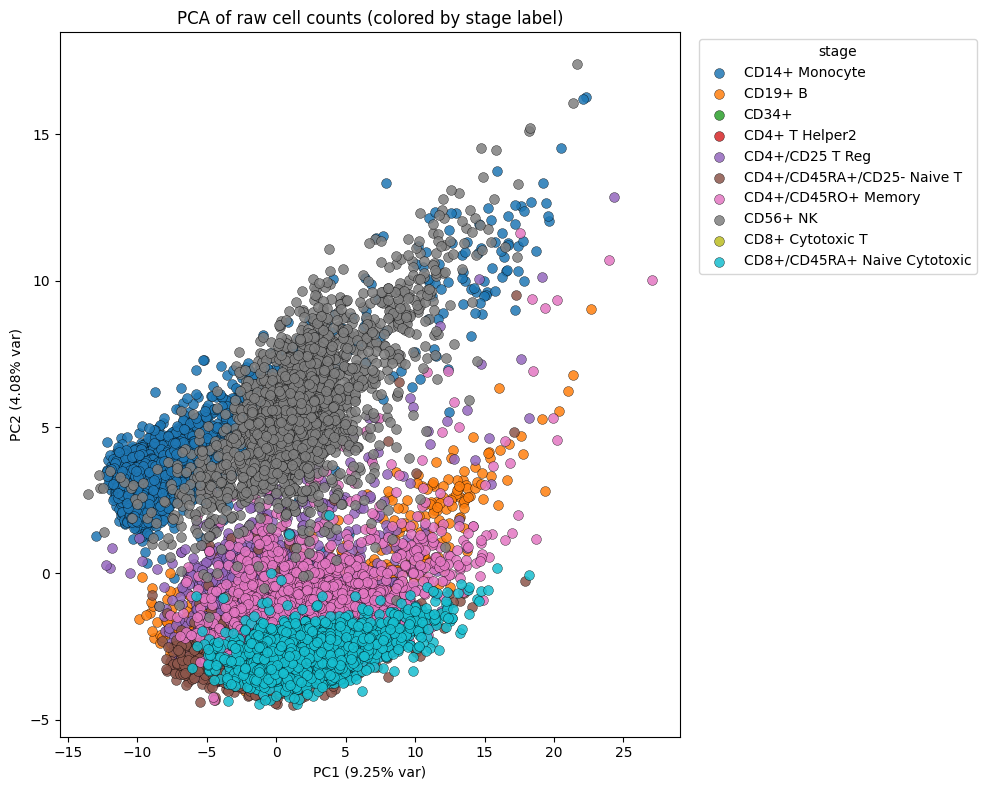

In [15]:
pca = PCA(n_components=2, random_state=0)
pcs = pca.fit_transform(X)

pc_df = pd.DataFrame(pcs, columns=['PC1', 'PC2'])
pc_df['label'] = y.values

plt.figure(figsize=(10, 8))
labels = pd.Categorical(pc_df['label']).categories
cmap = plt.get_cmap('tab10')
color_map = {lab: cmap(i % 10) for i, lab in enumerate(labels)}

for lab in labels:
    sel = pc_df[pc_df['label'] == lab]
    plt.scatter(sel['PC1'], sel['PC2'], label=lab, color=color_map[lab], s=50, alpha=0.85, edgecolor='k', linewidth=0.3)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% var)")
plt.title("PCA of raw cell counts (colored by stage label)")
plt.legend(title='stage', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 2.4 Perform Clustering with "Oracle" Number of Clusters:

In [16]:
from sklearn.model_selection import StratifiedShuffleSplit

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.10, random_state=RANDOM_SEED)
sub_idx = next(sss.split(X, y))[1]

X_sub = X[sub_idx]
y_sub = y[sub_idx]

print("Subsampled X shape:", X_sub.shape)
print("Subsampled y shape:", y_sub.shape)
print("Label distribution in subsample:", pd.Series(y_sub).value_counts().head())

Subsampled X shape: (1400, 21952)
Subsampled y shape: (1400,)
Label distribution in subsample: cell_type
CD14+ Monocyte                200
CD19+ B                       200
CD4+/CD25 T Reg               200
CD4+/CD45RA+/CD25- Naive T    200
CD4+/CD45RO+ Memory           200
Name: count, dtype: int64


/var/folders/l_/sb8sl5s14cxc7f15c67l1lg00000gn/T/ipykernel_88333/3147323595.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_sub = y[sub_idx]


In [ ]:
n_clusters = len(np.unique(y))

# KMeans
kmeans = KMeans(n_clusters=n_clusters, random_state=RANDOM_SEED)
kmeans_labels = kmeans.fit_predict(X_sub)
ari_kmeans = adjusted_rand_score(y_sub, kmeans_labels)

# Agglomerative (Ward linkage)
agg = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
agg_labels = agg.fit_predict(X_sub)
ari_agg = adjusted_rand_score(y_sub, agg_labels)

# Leiden
leiden = LeidenClustering(n_clusters=n_clusters, random_state=RANDOM_SEED)
leiden_labels = leiden.fit_predict(X_sub)
ari_leiden = adjusted_rand_score(y_sub, leiden_labels)

# Spectral Clustering (median heuristic for gamma)
gamma = gamma_quantile_approx(X, q=0.50, random_state=RANDOM_SEED)
spectral = SpectralClustering(n_clusters=n_clusters, affinity='rbf', gamma=gamma, random_state=RANDOM_SEED)
spectral_labels = spectral.fit_predict(X_sub)
ari_spectral = adjusted_rand_score(y_sub, spectral_labels)

print(f"ARI KMeans: {ari_kmeans:.4f}")
print(f"ARI Agglomerative (Ward): {ari_agg:.4f}")
print(f"ARI Leiden: {ari_leiden:.4f}")
print(f"ARI Spectral (gamma={gamma:.6f}): {ari_spectral:.4f}")

ARI KMeans: 0.4475
ARI Agglomerative (Ward): 0.3476
ARI Leiden: 0.4991
ARI Spectral (gamma=0.000941): 0.3964


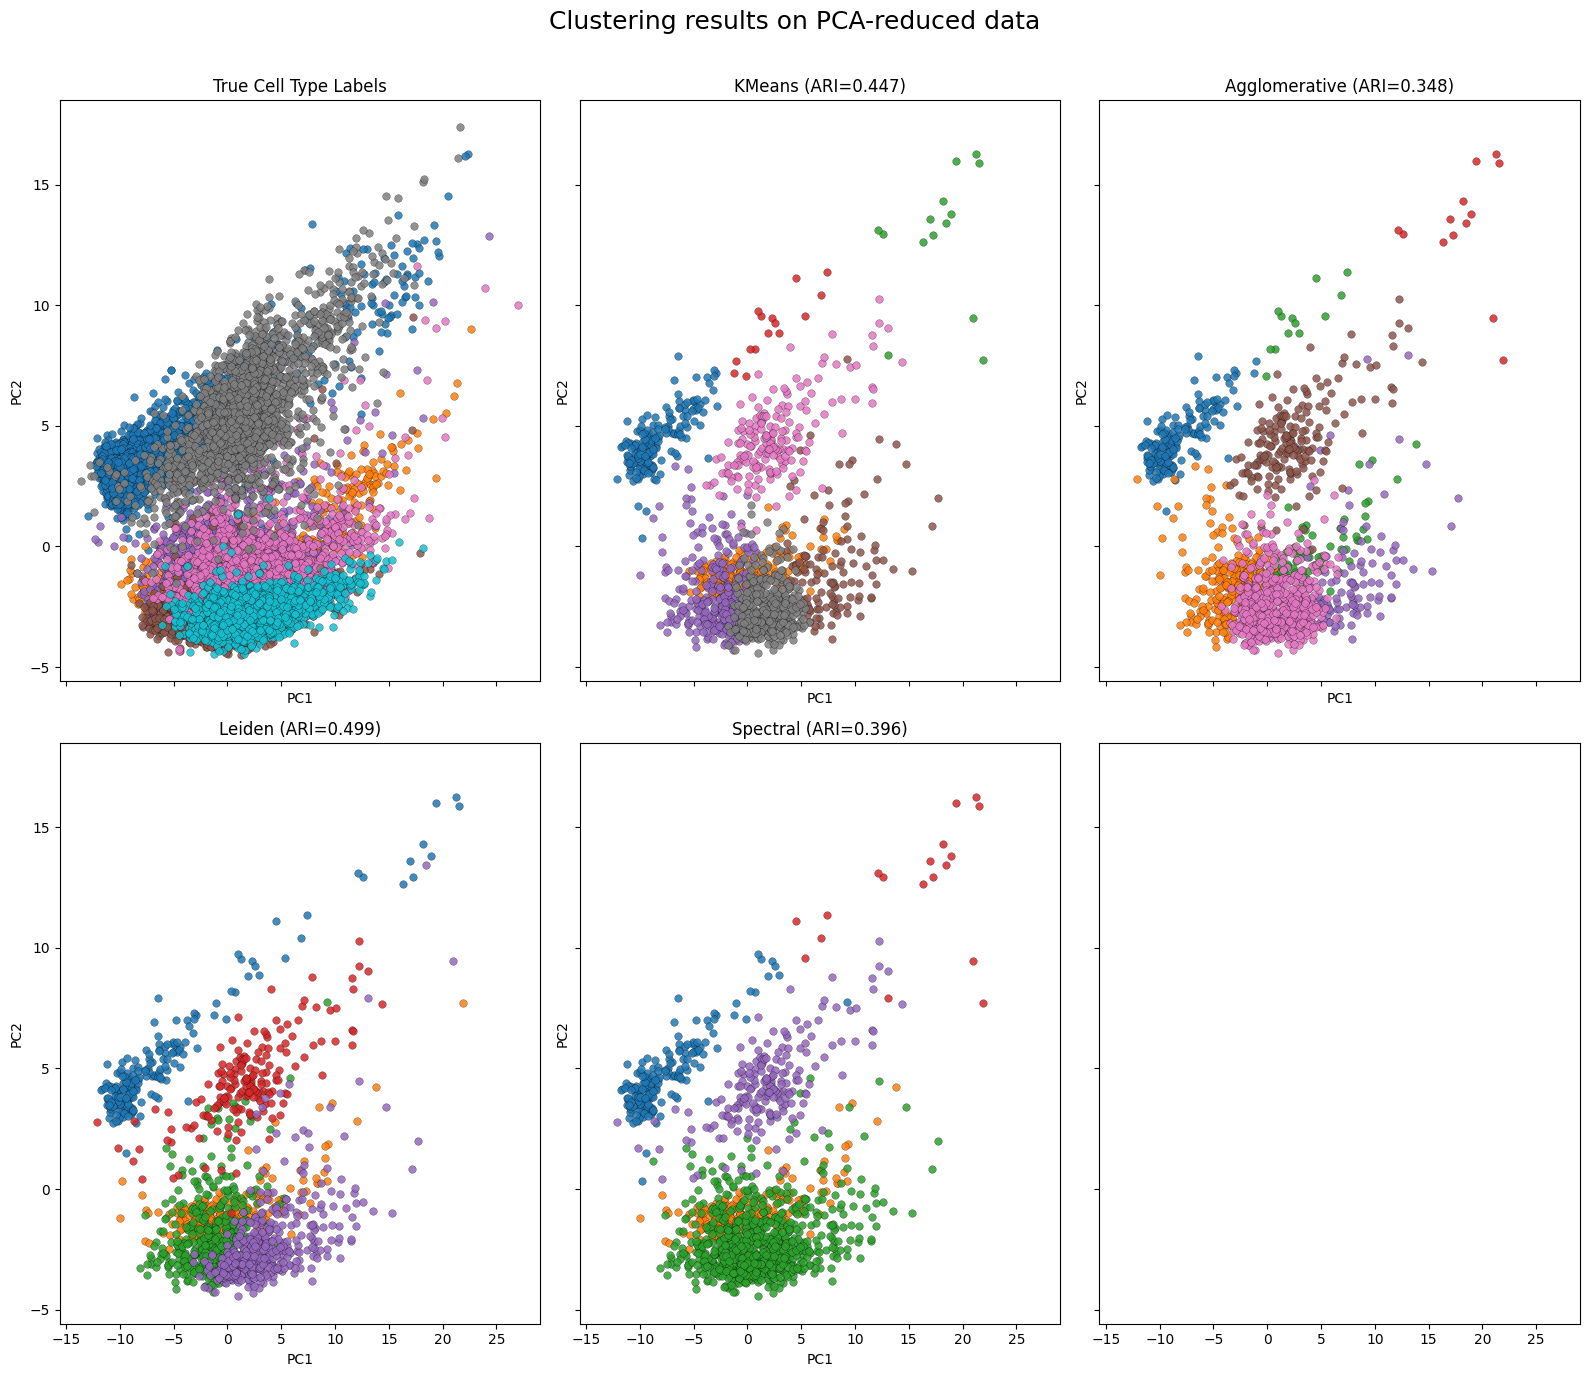

In [29]:
# PCA on X_sub
pca_sub = PCA(n_components=2, random_state=0)
pcs_sub = pca_sub.fit_transform(X_sub)
pc_df_sub = pd.DataFrame(pcs_sub, columns=['PC1', 'PC2'])
pc_df_sub['label'] = y_sub.values

fig, axes = plt.subplots(2, 3, figsize=(16, 14), sharex=True, sharey=True)

# Plot true labels
ax_true = axes[0, 0]
for lab in pd.Categorical(y).categories:
    sel = pc_df['label'] == lab
    ax_true.scatter(pc_df.loc[sel, 'PC1'], pc_df.loc[sel, 'PC2'], s=30, alpha=0.85, edgecolor='k', linewidth=0.2, label=lab)
ax_true.set_title("True Cell Type Labels")
ax_true.set_xlabel("PC1")
ax_true.set_ylabel("PC2")
# ax_true.legend(markerscale=1.5, bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)

titles = [
    f"KMeans (ARI={ari_kmeans:.3f})",
    f"Agglomerative (ARI={ari_agg:.3f})",
    f"Leiden (ARI={ari_leiden:.3f})",
    f"Spectral (ARI={ari_spectral:.3f})"
]
clusterings = [kmeans_labels, agg_labels, leiden_labels, spectral_labels]

aligned_clusterings = [align_labels(pd.Categorical(y_sub).codes, labels) for labels in clusterings]

for ax, labels, title in zip(axes.flat[1:], aligned_clusterings, titles):
    for cluster in np.unique(labels):
        sel = labels == cluster
        ax.scatter(
            pc_df_sub.loc[labels == cluster, 'PC1'],
            pc_df_sub.loc[labels == cluster, 'PC2'],
            s=30, alpha=0.85, edgecolor='k', linewidth=0.2, label=f"Cluster {cluster}"
        )
    ax.set_title(title)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    # ax.legend(markerscale=1.5, bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)

plt.suptitle("Clustering results on PCA-reduced data", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

---

## 3. Run Silhouette, Gap Statistic, Calinski Harabasz, and Davies Bouldin:

In [19]:
K = 12
ks = np.arange(3, K+1)

gamma_005 = gamma_quantile_approx(X, q=0.05, random_state=RANDOM_SEED)
gamma_01 = gamma_quantile_approx(X, q=0.1, random_state=RANDOM_SEED)
gamma_05 = gamma_quantile_approx(X, q=0.5, random_state=RANDOM_SEED)

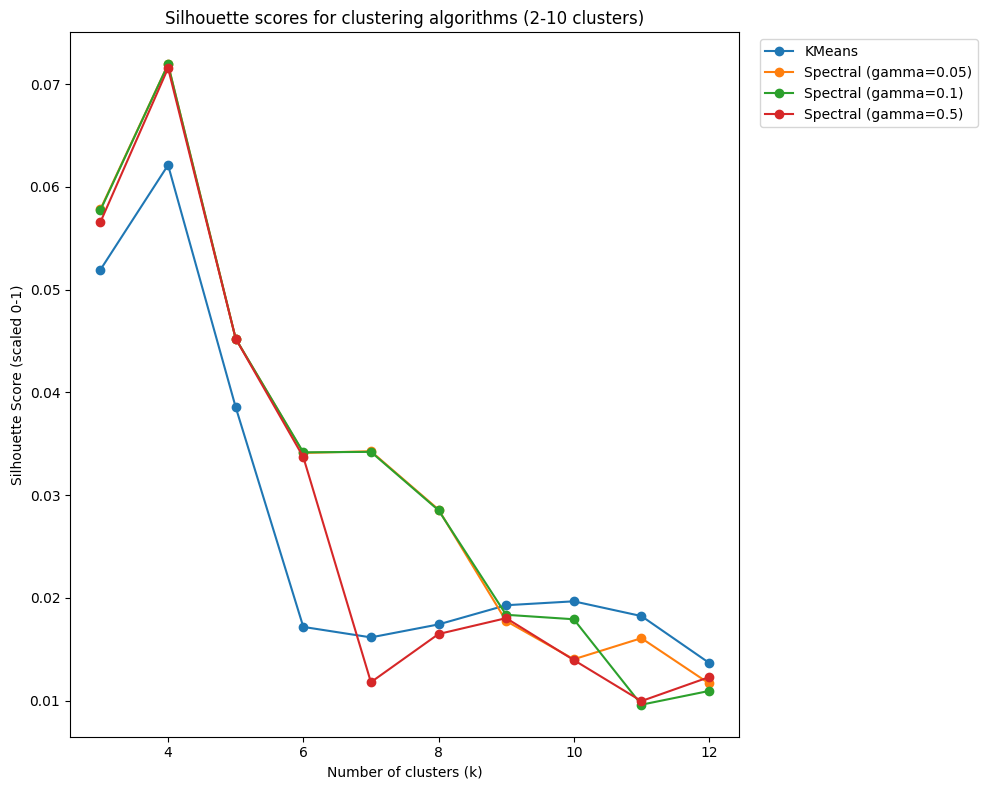

In [ ]:
silhouette_scores_kmeans = []
silhouette_scores_spectral_005 = []
silhouette_scores_spectral_01 = []
silhouette_scores_spectral_05 = []

for k in ks:
    # KMeans
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_SEED)
    labels_kmeans = kmeans.fit_predict(X_sub)
    sil_kmeans = silhouette_score(X_sub, labels_kmeans)
    silhouette_scores_kmeans.append(sil_kmeans)
    
    # Agglomerative (Ward)
    # agg = AgglomerativeClustering(n_clusters=k, linkage='ward')
    # labels_agg = agg.fit_predict(X_sub)
    # sil_agg = silhouette_score(X_sub, labels_agg)
    # silhouette_scores_agg.append(sil_agg)
    
    # Spectral Clustering (median heuristic for gamma)
    spectral_005 = SpectralClustering(n_clusters=k, affinity='rbf', gamma=gamma_005, random_state=RANDOM_SEED)
    labels_spectral_005 = spectral_005.fit_predict(X_sub)
    sil_spectral_005 = silhouette_score(X_sub, labels_spectral_005)
    silhouette_scores_spectral_005.append(sil_spectral_005) 
    
    spectral_01 = SpectralClustering(n_clusters=k, affinity='rbf', gamma=gamma_01, random_state=RANDOM_SEED)
    labels_spectral_01 = spectral_01.fit_predict(X_sub)
    sil_spectral_01 = silhouette_score(X_sub, labels_spectral_01)
    silhouette_scores_spectral_01.append(sil_spectral_01)
    
    spectral_05 = SpectralClustering(n_clusters=k, affinity='rbf', gamma=gamma_05, random_state=RANDOM_SEED)
    labels_spectral_05 = spectral_05.fit_predict(X_sub)
    sil_spectral_05 = silhouette_score(X_sub, labels_spectral_05)
    silhouette_scores_spectral_05.append(sil_spectral_05)

# Scale all scores to [0, 1]
# scaler = MinMaxScaler()
# silhouette_scores_kmeans_scaled = scaler.fit_transform(np.array(silhouette_scores_kmeans).reshape(-1, 1)).flatten()
# silhouette_scores_agg_scaled = scaler.fit_transform(np.array(silhouette_scores_agg).reshape(-1, 1)).flatten()
# silhouette_scores_spectral_scaled = scaler.fit_transform(np.array(silhouette_scores_spectral).reshape(-1, 1)).flatten()

plt.figure(figsize=(10, 8))
plt.plot(ks, silhouette_scores_kmeans, label='KMeans', marker='o')
plt.plot(ks, silhouette_scores_spectral_005, label='Spectral (gamma=0.05)', marker='o')
plt.plot(ks, silhouette_scores_spectral_01, label='Spectral (gamma=0.1)', marker='o')
plt.plot(ks, silhouette_scores_spectral_05, label='Spectral (gamma=0.5)', marker='o')

plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score (scaled 0-1)')
plt.title('Silhouette scores for clustering algorithms (2-10 clusters)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [20]:
# Stack all silhouette score arrays
all_scores = np.array([
    silhouette_scores_kmeans,
    silhouette_scores_spectral_005,
    silhouette_scores_spectral_01,
    silhouette_scores_spectral_05
])

# Find the (method, k) where the silhouette is maximized
max_idx = np.unravel_index(np.argmax(all_scores), all_scores.shape)
method_names = [
    "KMeans",
    "Spectral (gamma=0.05)",
    "Spectral (gamma=0.1)",
    "Spectral (gamma=0.5)"
]
best_method = method_names[max_idx[0]]
best_k = ks[max_idx[1]]
best_score = all_scores[max_idx]

print(f"Max silhouette score is {best_score:.4f} for {best_method} at k={best_k}")

Max silhouette score is 0.0719 for Spectral (gamma=0.05) at k=4


---

## 4. Run CARVE:

In [20]:
# model_grids = [
#     (KMeans, {"n_clusters": ks}), 
#     (AgglomerativeClustering, {"n_clusters": ks, "linkage": ["ward"]}), 
#     (SpectralClustering, {"n_clusters": ks, "gamma": [gamma]})
# ]

model_grids = [
    (KMeans, {"n_clusters": ks}), 
    (SpectralClustering, {"n_clusters": ks, "gamma": [gamma_005, gamma_01, gamma_05]})
]

carve = CARVE(
    model_grids=model_grids,
    n_jobs=N_JOBS,
    random_state=RANDOM_SEED
)

carve.fit(X_sub, ref_labels=y_sub)

[CARVE] ============================================================
[CARVE] Validation Settings:
[CARVE] n_samples          : 1400
[CARVE] n_features         : 21952
[CARVE] K                  : 10
[CARVE] B (resamples)      : 100
[CARVE] rho (subsampling)  : 0.6
[CARVE] n_jobs             : 10
[CARVE] total configs      : 40
[CARVE] random_preprocess  : False
[CARVE] random_state       : 42
[CARVE] ============================================================

[CARVE] Starting validation ...

[CARVE] [1/40] est=KMeans n_clusters=3 | ARI_stab=0.467±0.029  ARI_gen=0.369±0.022  ARI_avg=0.418±0.020
[CARVE] [2/40] est=KMeans n_clusters=4 | ARI_stab=0.536±0.021  ARI_gen=0.487±0.022  ARI_avg=0.511±0.016
[CARVE] [3/40] est=KMeans n_clusters=5 | ARI_stab=0.532±0.020  ARI_gen=0.511±0.016  ARI_avg=0.521±0.013
[CARVE] [4/40] est=KMeans n_clusters=6 | ARI_stab=0.566±0.015  ARI_gen=0.542±0.016  ARI_avg=0.554±0.011
[CARVE] [5/40] est=KMeans n_clusters=7 | ARI_stab=0.570±0.015  ARI_gen=0.559±0.014  A

,K,10
,B,100
,rho,0.6
,model_grids,"[(<class 'sklea...means.KMeans'>, ...), (<class 'sklea...alClustering'>, ...)]"
,norm_options,None
,dr_options,None
,ref_labels,array(['CD4+/... dtype=object)
,n_jobs,10
,random_state,42
,verbose,1


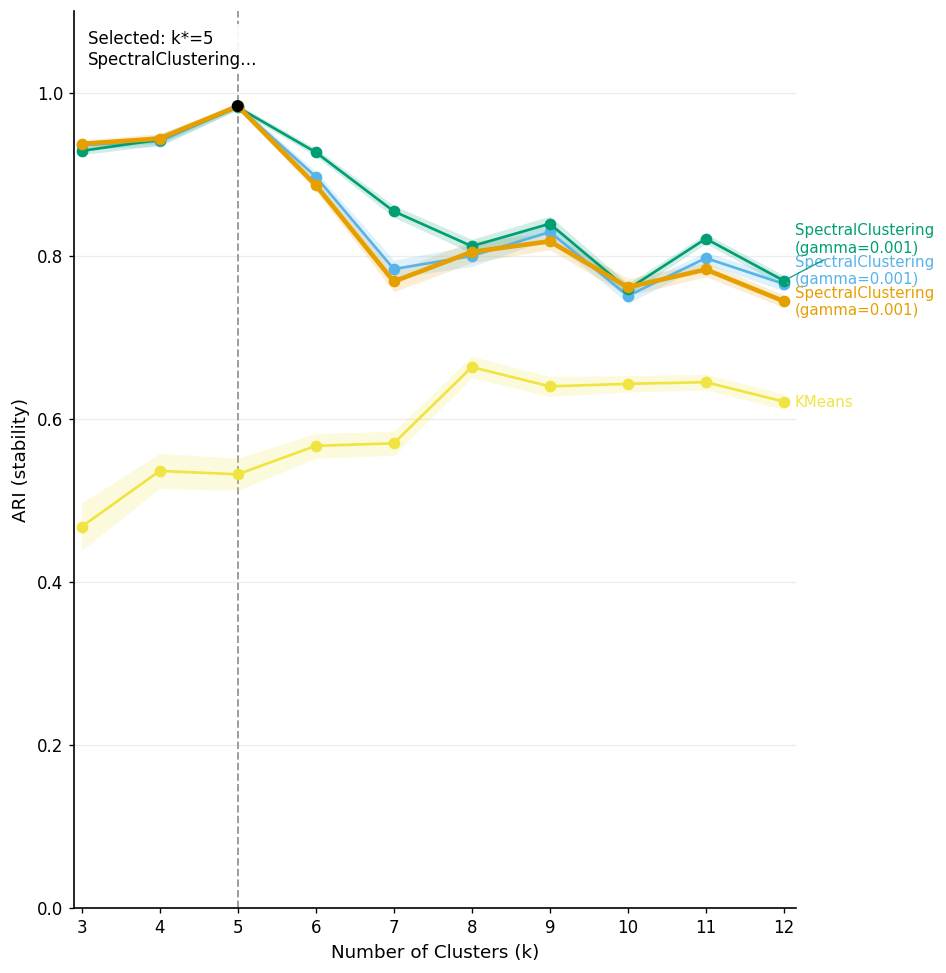

In [21]:
carve.plot_results(measure='ari_stability', rule='1se', interactive=False)

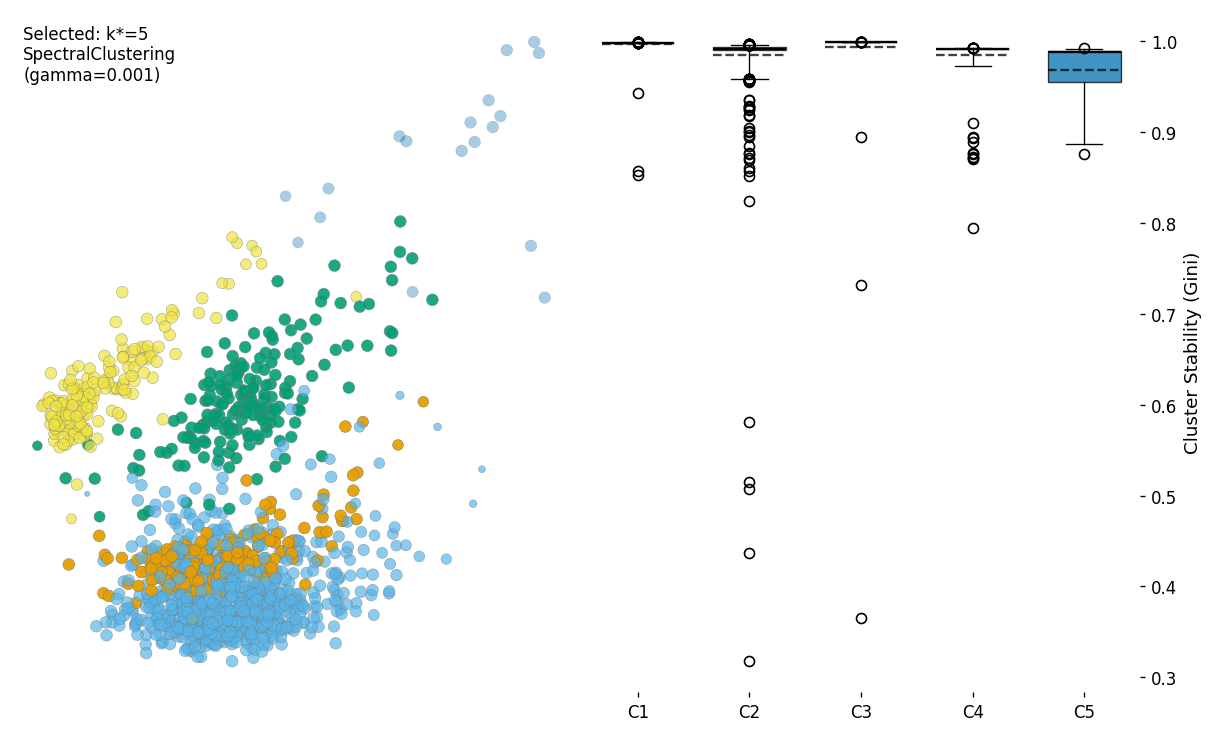

In [25]:
carve.plot_clustering(measure='generalizability', rule='1se', interactive=False)

In [44]:
# pip if needed:
# %pip install -q plotly kaleido

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import matplotlib.pyplot as plt

def _unique_in_order(x):
    seen = set()
    out = []
    for v in x:
        if v not in seen:
            out.append(v)
            seen.add(v)
    return out

def _hex_to_rgba(hex_color, a=0.35):
    hex_color = hex_color.lstrip("#")
    r = int(hex_color[0:2], 16)
    g = int(hex_color[2:4], 16)
    b = int(hex_color[4:6], 16)
    return f"rgba({r},{g},{b},{a})"

def alluvial_compare(
    y_true,
    left_labels,
    right_labels,
    left_title="CARVE (spectral)",
    right_title="silhouette (agg/ward)",
    true_title="true label",
    palette_name="tab10",
    link_alpha=0.35,
    node_pad=20,
    node_thickness=18,
    font_size=14,
    height=600,
    width=1200,
):
    # --- coerce to strings for clean labeling ---
    y_true = pd.Series(y_true).astype(str).to_numpy()
    left_labels = pd.Series(left_labels).astype(int).to_numpy()
    right_labels = pd.Series(right_labels).astype(int).to_numpy()

    n = len(y_true)
    assert len(left_labels) == n and len(right_labels) == n, "length mismatch"

    # --- order true labels by first appearance (closest to how people expect them) ---
    true_order = _unique_in_order(y_true)

    # --- order clusters numerically, show as 1..K ---
    left_order = sorted(np.unique(left_labels))
    right_order = sorted(np.unique(right_labels))

    # --- colors: assign a stable color per TRUE label ---
    cmap = plt.get_cmap(palette_name)
    true_colors = {lab: "#{:02x}{:02x}{:02x}".format(
        int(255*cmap(i % cmap.N)[0]),
        int(255*cmap(i % cmap.N)[1]),
        int(255*cmap(i % cmap.N)[2]),
    ) for i, lab in enumerate(true_order)}

    # --- helper: compute purity + share and dominant true label per predicted cluster ---
    def cluster_stats(pred):
        df = pd.DataFrame({"pred": pred, "true": y_true})
        ct = pd.crosstab(df["pred"], df["true"]).reindex(index=sorted(df["pred"].unique()), columns=true_order, fill_value=0)
        sizes = ct.sum(axis=1).to_numpy()
        shares = sizes / n
        dom_true = ct.idxmax(axis=1).to_numpy()
        purities = (ct.max(axis=1).to_numpy() / np.maximum(sizes, 1))
        return ct, sizes, shares, dom_true, purities

    ct_left, _, share_left, dom_left, pur_left = cluster_stats(left_labels)
    ct_right, _, share_right, dom_right, pur_right = cluster_stats(right_labels)

    # --- node labels (match screenshot style: big purity %, then share %) ---
    left_node_labels = []
    left_node_colors = []
    for i, k in enumerate(left_order):
        purity = pur_left[i]
        share = share_left[i]
        left_node_labels.append(f"{k+1}<br>{purity*100:.0f}%<br>{share*100:.0f}%")
        left_node_colors.append(true_colors[dom_left[i]])

    true_node_labels = [lab for lab in true_order]
    true_node_colors = [true_colors[lab] for lab in true_order]

    right_node_labels = []
    right_node_colors = []
    for i, k in enumerate(right_order):
        purity = pur_right[i]
        share = share_right[i]
        right_node_labels.append(f"{k+1}<br>{purity*100:.0f}%<br>{share*100:.0f}%")
        right_node_colors.append(true_colors[dom_right[i]])

    # --- node indexing ---
    nL = len(left_order)
    nT = len(true_order)
    nR = len(right_order)

    idx_left = {k: i for i, k in enumerate(left_order)}
    idx_true = {lab: nL + i for i, lab in enumerate(true_order)}
    idx_right = {k: nL + nT + i for i, k in enumerate(right_order)}

    # --- links: left -> true and true -> right, colored by TRUE label ---
    sources = []
    targets = []
    values = []
    colors = []

    # left -> true
    for k in left_order:
        for lab in true_order:
            v = int(ct_left.loc[k, lab]) if (k in ct_left.index and lab in ct_left.columns) else 0
            if v > 0:
                sources.append(idx_left[k])
                targets.append(idx_true[lab])
                values.append(v)
                colors.append(_hex_to_rgba(true_colors[lab], link_alpha))

    # true -> right
    ct_tr = pd.crosstab(pd.Series(y_true, name="true"), pd.Series(right_labels, name="pred")).reindex(index=true_order, columns=right_order, fill_value=0)
    for lab in true_order:
        for k in right_order:
            v = int(ct_tr.loc[lab, k])
            if v > 0:
                sources.append(idx_true[lab])
                targets.append(idx_right[k])
                values.append(v)
                colors.append(_hex_to_rgba(true_colors[lab], link_alpha))

    # --- fixed 3-column layout (x positions), evenly spaced y positions per column ---
    def col_positions(m, top=0.02, bottom=0.98):
        if m == 1:
            return [0.5]
        return list(np.linspace(top, bottom, m))

    x = ([0.0]*nL) + ([0.5]*nT) + ([1.0]*nR)
    y = (col_positions(nL)) + (col_positions(nT)) + (col_positions(nR))

    fig = go.Figure(go.Sankey(
        arrangement="fixed",
        node=dict(
            pad=node_pad,
            thickness=node_thickness,
            line=dict(color="rgba(0,0,0,0.25)", width=0.5),
            label=left_node_labels + true_node_labels + right_node_labels,
            color=left_node_colors + true_node_colors + right_node_colors,
            x=x,
            y=y,
        ),
        link=dict(
            source=sources,
            target=targets,
            value=values,
            color=colors,
        )
    ))

    fig.update_layout(
        font=dict(size=font_size, family="Arial"),
        paper_bgcolor="white",
        plot_bgcolor="white",
        width=width,
        height=height,
        margin=dict(l=40, r=40, t=60, b=20),
        annotations=[
            dict(x=0.0, y=1.08, xref="paper", yref="paper", text=left_title, showarrow=False, font=dict(size=font_size+2)),
            dict(x=0.5, y=1.08, xref="paper", yref="paper", text=true_title, showarrow=False, font=dict(size=font_size+2)),
            dict(x=1.0, y=1.08, xref="paper", yref="paper", text=right_title, showarrow=False, font=dict(size=font_size+2)),
        ],
    )
    return fig


In [ ]:
# Agglomerative k=4 (Ward) –– as suggested by silhouette 
agg_labels = AgglomerativeClustering(n_clusters=3, linkage='ward').fit_predict(X_sub) 

# Spectral, k=7 –– as suggested by CARVE generalizability 
spectral_labels = SpectralClustering(n_clusters=7, gamma=gamma_quantiles_approx(X_sub, qs=(0.50,), random_state=RANDOM_SEED)[0]).fit_predict(X_sub)

fig = alluvial_compare(
    y_true=y_sub,
    left_labels=spectral_labels,   # CARVE choice
    right_labels=agg_labels,       # silhouette choice
    left_title="CARVE (spectral)",
    right_title="silhouette (agg/ward)",
    true_title="true label",
    palette_name="tab10",
    link_alpha=0.35,
)

fig.show()


---